In [2]:
!pip install shap lime dice-ml

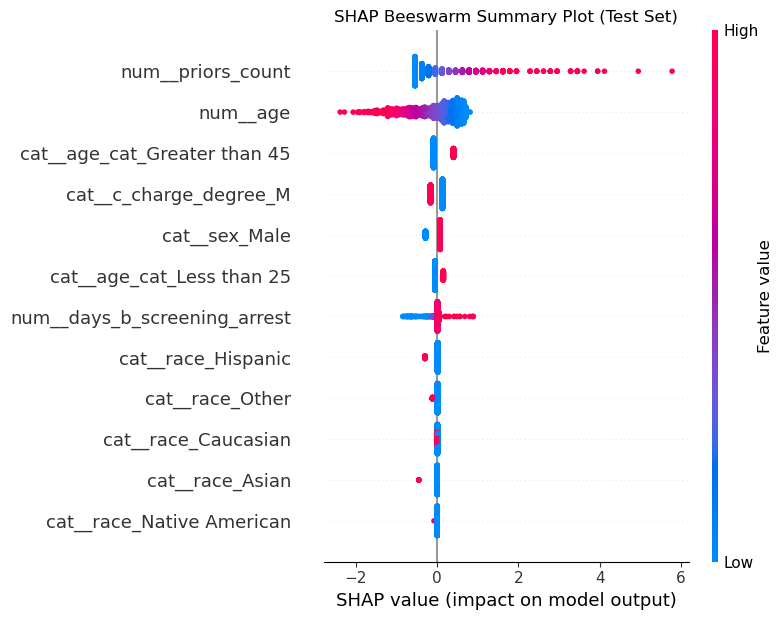

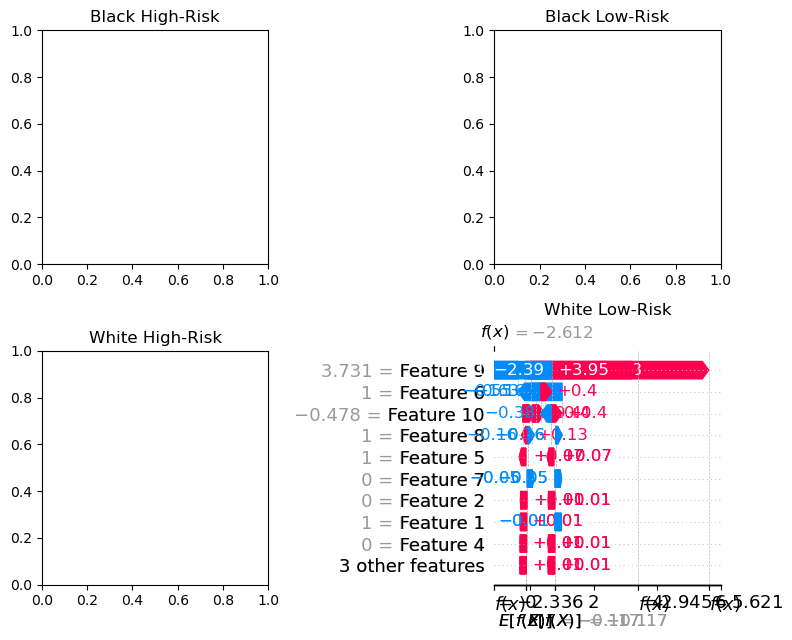


=== LIME Explanation: Black High-Risk ===
[('num__priors_count > 0.16', 0.28728013861490675), ('num__age > 0.56', -0.2609991659646531), ('cat__age_cat_Greater than 45 > 0.00', 0.10194700103825077), ('cat__race_Asian <= 0.00', 0.08864795491314781), ('cat__c_charge_degree_M <= 0.00', 0.06295693692542413), ('num__days_b_screening_arrest <= 0.15', -0.05384750948863796), ('cat__race_Hispanic <= 0.00', 0.04949054834060737), ('cat__age_cat_Less than 25 <= 0.00', -0.03743272132243208)]

=== LIME Explanation: Black Low-Risk ===
[('num__age > 0.56', -0.2649547368772484), ('cat__race_Asian <= 0.00', 0.0987055835148852), ('cat__age_cat_Greater than 45 > 0.00', 0.09823968858332129), ('cat__race_Hispanic <= 0.00', 0.06668534188359647), ('0.00 < cat__c_charge_degree_M <= 1.00', -0.06341661822141709), ('num__priors_count <= -0.69', -0.06168384274922045), ('cat__age_cat_Less than 25 <= 0.00', -0.04973018515276137), ('cat__race_Native American <= 0.00', 0.03844185627656167)]

=== LIME Explanation: Whit

100%|████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 12.00it/s]


=== Counterfactual for Black High-Risk ===
Query instance (original outcome : 1)


,age,c_charge_degree,race,age_cat,sex,priors_count,days_b_screening_arrest,two_year_recid
0,45,F,African-American,Greater than 45,Male,38,-1.0,1



Diverse Counterfactual set (new outcome: 0)


...


=== Counterfactual for White Low-Risk ===
Query instance (original outcome : 0)


,age,c_charge_degree,race,age_cat,sex,priors_count,days_b_screening_arrest,two_year_recid
0,78,M,Caucasian,Greater than 45,Male,1,-1.0,0



Diverse Counterfactual set (new outcome: 1)


,age,c_charge_degree,race,age_cat,sex,priors_count,days_b_screening_arrest,two_year_recid
0,-,-,-,Less than 25,-,30,-,1


Check above for changes to immutable features (race, sex)


In [7]:
# =============================================================================
# DNSC 6330 - Individual Homework 2: Explaining the COMPAS Replacement Model
# Author: Farid Samedli
# Date: March 2026
# =============================================================================

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
import shap
from lime.lime_tabular import LimeTabularExplainer
import dice_ml
import matplotlib.pyplot as plt

# Load & preprocess
url = "https://raw.githubusercontent.com/propublica/compas-analysis/master/compas-scores-two-years.csv"
df = pd.read_csv(url)[['age', 'c_charge_degree', 'race', 'age_cat', 'sex', 
                       'priors_count', 'days_b_screening_arrest', 'is_recid', 
                       'two_year_recid']].copy()

df = df[(df['days_b_screening_arrest'] >= -30) & (df['days_b_screening_arrest'] <= 30)]
df = df[(df['is_recid'] != -1) & (df['c_charge_degree'] != 'O') & df['two_year_recid'].notna()]

X = df.drop(columns=['two_year_recid', 'is_recid'])
y = df['two_year_recid'].astype(int)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Pipeline
cat = ['race', 'sex', 'age_cat', 'c_charge_degree']
num = ['age', 'priors_count', 'days_b_screening_arrest']

model = Pipeline([
    ('prep', ColumnTransformer([('cat', OneHotEncoder(drop='first'), cat),
                                ('num', StandardScaler(), num)])),
    ('clf', LogisticRegression(max_iter=1000))
]).fit(X_train, y_train)

# SHAP
explainer = shap.Explainer(model.named_steps['clf'], model.named_steps['prep'].transform(X_test))
shap_values = explainer(model.named_steps['prep'].transform(X_test))

shap.summary_plot(shap_values, model.named_steps['prep'].transform(X_test),
                  feature_names=model.named_steps['prep'].get_feature_names_out(), show=False)
plt.title("SHAP Beeswarm Summary Plot (Test Set)")
plt.tight_layout()
plt.show()

# 4 individuals
test_df = X_test.copy().reset_index(drop=True)
test_df['pred_prob'] = model.predict_proba(X_test)[:, 1]
test_df['race'] = X_test['race'].values

black = test_df[test_df['race'] == 'African-American']
white = test_df[test_df['race'] == 'Caucasian']

indices = [black.nlargest(1, 'pred_prob').index[0], black.nsmallest(1, 'pred_prob').index[0],
           white.nlargest(1, 'pred_prob').index[0], white.nsmallest(1, 'pred_prob').index[0]]
labels  = ["Black High-Risk", "Black Low-Risk", "White High-Risk", "White Low-Risk"]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for ax, i, lab in zip(axes.flatten(), indices, labels):
    shap.waterfall_plot(shap_values[i], max_display=10, show=False)
    ax.set_title(lab)
plt.tight_layout()
plt.show()

# LIME
lime_exp = LimeTabularExplainer(model.named_steps['prep'].transform(X_train),
                                feature_names=model.named_steps['prep'].get_feature_names_out(),
                                class_names=['No Recidivism', 'Recidivism'], mode='classification')

for i, lab in zip(indices, labels):
    exp = lime_exp.explain_instance(model.named_steps['prep'].transform(X_test)[i],
                                    model.named_steps['clf'].predict_proba, num_features=8)
    print(f"\n=== LIME Explanation: {lab} ===")
    print(exp.as_list())

# DiCE
df_dice = X.copy()
df_dice['two_year_recid'] = y
dice_data = dice_ml.Data(dataframe=df_dice, continuous_features=num, outcome_name='two_year_recid')
dice_exp = dice_ml.Dice(dice_data, dice_ml.Model(model=model, backend='sklearn'), method='random')

for i, lab in zip(indices, labels):
    cf = dice_exp.generate_counterfactuals(X_test.iloc[[i]], total_CFs=1, desired_class="opposite")
    print(f"\n=== Counterfactual for {lab} ===")
    cf.visualize_as_dataframe(show_only_changes=True)
    print("Check above for changes to immutable features (race, sex)")